# Section A — Concept Application
##### Question 1 

In [ ]:
'''I would choose median imputation for delivery_time_mins because 14% missing data is significant, so dropping those rows would result in considerable data 
loss. Delivery times are usually right-skewed, and the median is less affected by extreme values than the mean.'''

'''For customer_rating, first convert the column to numeric using:'''
# df["customer_rating"] = pd.to_numeric(df["customer_rating"], errors="coerce")

'''Then verify the data type before analysis:'''
# print(df["customer_rating"].dtype)

'Then verify the data type before analysis:'

##### Question 2

In [ ]:
'''Calculate the mean and standard deviation using np.mean() and np.std(). Create a boolean mask that checks which order counts are greater than mean + 1.5
   × std.'''
# mask = orders > (np.mean(orders) + 1.5 * np.std(orders))
# surge_revenue = revenue[mask]
# total_revenue = np.sum(surge_revenue)

'''A boolean mask is an array of True and False values used to filter elements. NumPy performs these operations element-wise and internally, avoiding Python
loops. Therefore, it is generally faster and more efficient for large arrays.'''

'A boolean mask is an array of True and False values used to filter elements. NumPy performs these operations element-wise and internally, avoiding Python\nloops. Therefore, it is generally faster and more efficient for large arrays.'

##### Question 3

In [ ]:
'''(a) Delivery time vs customer rating:

Analysis: Bivariate analysis
Chart: sns.scatterplot()
Reason: It shows the relationship between two numerical variables and helps identify correlation. A line plot is less suitable because the data is not a 
time series.'''

'''(b) Average order value across restaurant categories:

Analysis: Bivariate analysis
Chart: sns.boxplot()
Reason: It compares the distribution of a numerical variable across categories and shows median, spread, and outliers. A line plot is inappropriate because
restaurant categories are categorical, not continuous.'''


'(b) Average order value across restaurant categories:\n\nAnalysis: Bivariate analysis\nChart: sns.boxplot()\nReason: It compares the distribution of a numerical variable across categories and shows median, spread, and outliers. A line plot is inappropriate because\nrestaurant categories are categorical, not continuous.'

##### Question 4

In [ ]:
'''Use a LEFT JOIN because we need to show every restaurant, including those with no orders.'''
# SELECT r.name, COALESCE(SUM(o.order_value), 0) AS total_revenue
# FROM restaurants r
# LEFT JOIN orders o
# ON r.restaurant_id = o.restaurant_id
# GROUP BY r.restaurant_id, r.name;

'''LEFT JOIN: Keeps all rows from restaurants and shows 0 revenue for restaurants without orders.
INNER JOIN: Shows only restaurants that have matching orders, so restaurants with zero orders would be excluded.

Therefore, LEFT JOIN is the correct choice because it preserves unmatched rows from the restaurants table.'''

'LEFT JOIN: Keeps all rows from restaurants and shows 0 revenue for restaurants without orders.\nINNER JOIN: Shows only restaurants that have matching orders, so restaurants with zero orders would be excluded.\n\nTherefore, LEFT JOIN is the correct choice because it preserves unmatched rows from the restaurants table.'

##### Question 5

In [ ]:
'''Ranking function: RANK() — ranks delivery agents based on completed deliveries.
   Previous value: LAG() — retrieves the delivery count of the agent ranked directly above.'''

'''Use PARTITION BY city so ranking restarts for each city.'''

# RANK() OVER (PARTITION BY city ORDER BY completed_deliveries DESC)
# LAG(completed_deliveries) OVER (PARTITION BY city ORDER BY completed_deliveries DESC)

'''Why window functions? They calculate rankings and previous-row values directly while keeping individual agent records. GROUP BY with self-joins or 
correlated subqueries is more complex and harder to maintain. Window functions are clearer, more efficient, and accurately handle calculations within
each city.'''

'Why window functions? They calculate rankings and previous-row values directly while keeping individual agent records. GROUP BY with self-joins or \ncorrelated subqueries is more complex and harder to maintain. Window functions are clearer, more efficient, and accurately handle calculations within\neach city.'

##### Question 6

In [ ]:
'''CTE (WITH) is preferable for this two-step requirement because:

Readability: Separates the top-5 category calculation from the final query, making the SQL easier to understand.
Reusability: The intermediate result can be referenced multiple times within the same query.
Debugging: Each step can be tested separately, making errors easier to find.

A nested subquery is more compact but can become difficult to read and debug when deeply nested.

Prefer a nested subquery when the intermediate result is simple, used only once, and the query is short, because creating a CTE would add unnecessary 
structure.'''

'CTE (WITH) is preferable for this two-step requirement because:\n\nReadability: Separates the top-5 category calculation from the final query, making the SQL easier to understand.\nReusability: The intermediate result can be referenced multiple times within the same query.\nDebugging: Each step can be tested separately, making errors easier to find.\n\nA nested subquery is more compact but can become difficult to read and debug when deeply nested.\n\nPrefer a nested subquery when the intermediate result is simple, used only once, and the query is short, because creating a CTE would add unnecessary \nstructure.'

# <---------- Practical Task ---------->

<strong><strong>Task.1</strong></strong> :-<strong>Daily Order Analysis with NumPy</strong>

Build a NumPy-based program that analyses 30 days of order count and revenue data for a
food delivery platform

In [5]:
import numpy as np

np.random.seed(42)
orders = np.random.randint(100, 801, 30)
revenue = np.random.uniform(5000, 50000, 30)

total_orders = np.sum(orders)
total_revenue = np.sum(revenue)
mean_orders = np.mean(orders)
std_orders = np.std(orders)
highest_revenue_day = np.argmax(revenue) + 1

peak_days = orders > (mean_orders + std_orders)
peak_orders = orders[peak_days]
peak_revenue = revenue[peak_days]
peak_day_count = np.sum(peak_days)
peak_total_revenue = np.sum(peak_revenue)

weekly_orders = orders.reshape(5, 6)
weekly_totals = np.sum(weekly_orders, axis=1)

print("Daily Order Analysis")
print("-" * 40)

print("Daily Orders:")
print(orders)

print("\nDaily Revenue:")
print(np.round(revenue, 2))

print("\nTotal Orders:", total_orders)
print("Total Revenue: ₹", round(total_revenue, 2))

print("\nMean Daily Orders:", round(mean_orders, 2))
print("Standard Deviation:", round(std_orders, 2))

print("\nDay with Highest Revenue:", highest_revenue_day)
print("Highest Revenue: ₹", round(revenue[highest_revenue_day - 1], 2))

print("\nPeak Order Threshold:", round(mean_orders + std_orders, 2))
print("Number of Peak Days:", peak_day_count)
print("Peak Days:", np.where(peak_days)[0] + 1)
print("Total Revenue from Peak Days: ₹", round(peak_total_revenue, 2))

print("\n5 × 6 Weekly Order Matrix:")
print(weekly_orders)

print("\nTotal Orders for Each Weekly Block:")
print(weekly_totals)

Daily Order Analysis
----------------------------------------
Daily Orders:
[202 535 370 206 171 800 120 714 221 566 314 430 558 187 472 199 763 230
 761 408 443 591 513 485 291 376 260 559 413 121]

Daily Revenue:
[ 5317.98  6037.81 28614.86 22993.74  7099.95 48819.   15474.71  9077.29
 32827.37 22210.79 49245.39 26004.33 43697.32 35613.84 25272.47  5596.92
 47399.08 30347.97 22343.74  5718.48 15390.22 15846.15 35746.86 32449.85
 42493.77 12801.41 22597.73 13200.62 38991.26 24132.01]

Total Orders: 12279
Total Revenue: ₹ 743362.93

Mean Daily Orders: 409.3
Standard Deviation: 195.9

Day with Highest Revenue: 11
Highest Revenue: ₹ 49245.39

Peak Order Threshold: 605.2
Number of Peak Days: 4
Peak Days: [ 6  8 17 19]
Total Revenue from Peak Days: ₹ 127639.11

5 × 6 Weekly Order Matrix:
[[202 535 370 206 171 800]
 [120 714 221 566 314 430]
 [558 187 472 199 763 230]
 [761 408 443 591 513 485]
 [291 376 260 559 413 121]]

Total Orders for Each Weekly Block:
[2284 2365 2409 3201 2020]


In [6]:
import pandas as pd
import numpy as np

data = {
    "order_id": range(1001, 1021),
    
    "customer_name": [
        "Aarav", "Priya", "Rahul", "Neha", "Rohan",
        "Meera", "Karan", "Ananya", "Vivek", "Isha",
        "Arjun", "Pooja", "Dev", "Riya", "Kabir",
        "Sneha", "Yash", "Nisha", "Aditya", "Simran"
    ],
    "restaurant_name": [
        "Spice Hub", "Pizza Palace", "Burger Point", "South Express",
        "Green Bowl", "Spice Hub", "Pizza Palace", "Burger Point",
        "Food Corner", "Tasty Bites", "South Express", "Green Bowl",
        "Spice Hub", "Pizza Palace", "Burger Point", "Food Corner",
        "Tasty Bites", "South Express", "Green Bowl", "Spice Hub"
    ],
    "category": [
        "Indian", "Pizza", "Burger", "South Indian", "Healthy",
        "Indian", "Pizza", "Burger", "Chinese", "Indian",
        "South Indian", "Healthy", "Indian", "Pizza", "Burger",
        "Chinese", "Indian", "South Indian", "Healthy", "Indian"
    ],
    "delivery_time_mins": [
        32, 45, 28, 38, 25,
        35, 50, 30, 42, 36,
        40, 27, 33, 48, 29,
        41, 37, 35, 26, 31
    ],
    "order_value": [
        450, 750, 320, 550, 680,
        490, 820, 350, 620, 480,
        590, 710, 530, 900, 400,
        650, 560, 470, 730, 510
    ],
    "rating": [
        4.5, 4.2, 3.8, 4.7, 4.1,
        4.4, 3.9, 4.0, 4.3, 4.6,
        4.1, 4.5, 3.7, 4.8, 4.2,
        4.4, 4.0, 4.6, 4.3, 4.5
    ]
}

df = pd.DataFrame(data)
df

,order_id,customer_name,restaurant_name,category,delivery_time_mins,order_value,rating
0,1001,Aarav,Spice Hub,Indian,32,450,4.5
1,1002,Priya,Pizza Palace,Pizza,45,750,4.2
2,1003,Rahul,Burger Point,Burger,28,320,3.8
3,1004,Neha,South Express,South Indian,38,550,4.7
4,1005,Rohan,Green Bowl,Healthy,25,680,4.1
5,1006,Meera,Spice Hub,Indian,35,490,4.4
6,1007,Karan,Pizza Palace,Pizza,50,820,3.9
7,1008,Ananya,Burger Point,Burger,30,350,4.0
8,1009,Vivek,Food Corner,Chinese,42,620,4.3
9,1010,Isha,Tasty Bites,Indian,36,480,4.6


In [7]:
df.loc[2, "delivery_time_mins"] = np.nan
df.loc[7, "order_value"] = np.nan
df.loc[12, "rating"] = np.nan
df.loc[15, "category"] = np.nan
df.loc[18, "delivery_time_mins"] = np.nan

df = pd.concat([
    df,
    df.iloc[[3]],
    df.iloc[[8]],
    df.iloc[[14]]
], ignore_index=True)
print("Original Dataset:")
print(df)

print("\nNull Count Before Filling:")
print(df.isnull().sum())

df["delivery_time_mins"] = df["delivery_time_mins"].fillna(
    df["delivery_time_mins"].median()
)

df["order_value"] = df["order_value"].fillna(
    df["order_value"].median()
)

rating_mean = round(df["rating"].mean(), 1)

df["rating"] = df["rating"].fillna(rating_mean)

category_mode = df["category"].mode()[0]

df["category"] = df["category"].fillna(category_mode)

print("\nNull Count After Filling:")
print(df.isnull().sum())

print("\nRating Mean Used:", rating_mean)
print("Category Mode Used:", category_mode)

print("\nShape Before Deduplication:", df.shape)
df = df.drop_duplicates()
print("Shape After Deduplication:", df.shape)

Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)

print("\nIQR Analysis")
print("-" * 40)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

outliers = df[
    (df["order_value"] < lower_fence) |
    (df["order_value"] > upper_fence)
]
print("\nOutlier Rows:")
print(outliers)

df["order_value"] = df["order_value"].clip(
    lower=lower_fence,
    upper=upper_fence
)
print("\nFinal Dataset After Outlier Capping:")
print(df)
print("\nMaximum Order Value After Capping:",df["order_value"].max())

Original Dataset:
    order_id customer_name restaurant_name      category  delivery_time_mins  \
0       1001         Aarav       Spice Hub        Indian                32.0   
1       1002         Priya    Pizza Palace         Pizza                45.0   
2       1003         Rahul    Burger Point        Burger                 NaN   
3       1004          Neha   South Express  South Indian                38.0   
4       1005         Rohan      Green Bowl       Healthy                25.0   
5       1006         Meera       Spice Hub        Indian                35.0   
6       1007         Karan    Pizza Palace         Pizza                50.0   
7       1008        Ananya    Burger Point        Burger                30.0   
8       1009         Vivek     Food Corner       Chinese                42.0   
9       1010          Isha     Tasty Bites        Indian                36.0   
10      1011         Arjun   South Express  South Indian                40.0   
11      1012         P

File saved successfully as food_delivery_dashboard.png


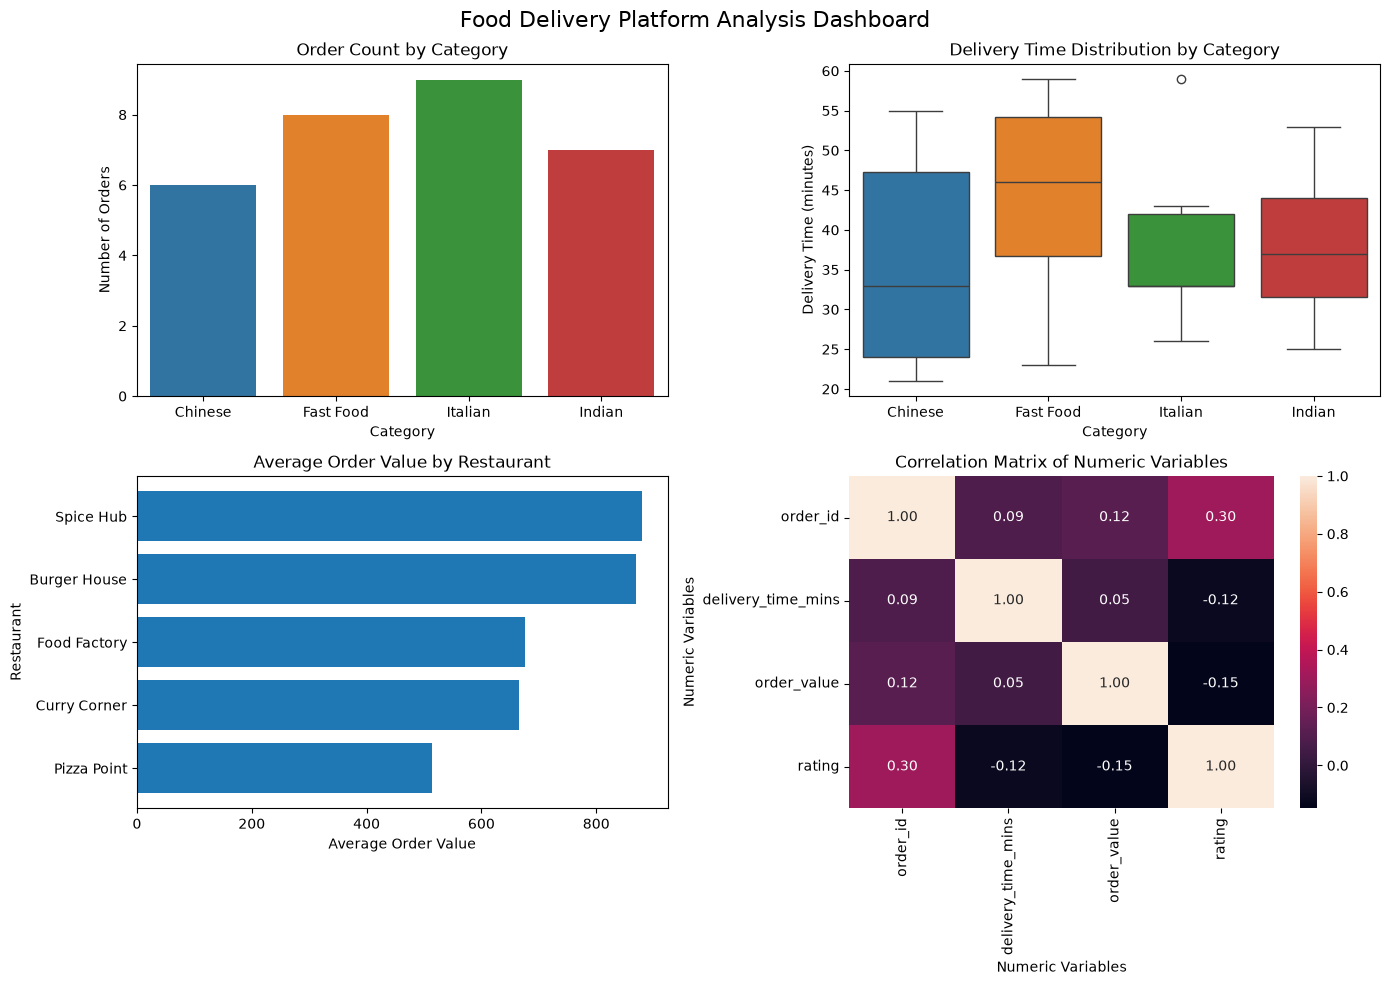

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 30
categories = ["Indian", "Italian", "Fast Food", "Chinese"]
restaurants = [
    "Spice Hub",
    "Pizza Point",
    "Burger House",
    "Curry Corner",
    "Food Factory"
]
df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "customer_name": [
        f"Customer_{i}" for i in range(1, n + 1)
    ],
    "restaurant_name": np.random.choice(
        restaurants, n
    ),
    "category": np.random.choice(
        categories, n
    ),
    "delivery_time_mins": np.random.randint(
        20, 61, n
    ),
    "order_value": np.random.uniform(
        250, 1200, n
    ).round(2),
    "rating": np.random.uniform(
        3.0, 5.0, n
    ).round(1)
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

sns.countplot(
    data=df,
    x="category",
    hue="category",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Order Count by Category"
)

axes[0, 0].set_xlabel(
    "Category"
)

axes[0, 0].set_ylabel(
    "Number of Orders"
)

sns.boxplot(
    data=df,
    x="category",
    y="delivery_time_mins",
    hue="category",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Delivery Time Distribution by Category"
)

axes[0, 1].set_xlabel(
    "Category"
)

axes[0, 1].set_ylabel(
    "Delivery Time (minutes)"
)

avg_order_value = (
    df.groupby("restaurant_name")["order_value"]
    .mean()
    .sort_values()
)

axes[1, 0].barh(
    avg_order_value.index,
    avg_order_value.values
)

axes[1, 0].set_title(
    "Average Order Value by Restaurant"
)

axes[1, 0].set_xlabel(
    "Average Order Value"
)

axes[1, 0].set_ylabel(
    "Restaurant"
)

numeric_df = df.select_dtypes(
    include="number"
)

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Correlation Matrix of Numeric Variables"
)

axes[1, 1].set_xlabel(
    "Numeric Variables"
)

axes[1, 1].set_ylabel(
    "Numeric Variables"
)

fig.suptitle(
    "Food Delivery Platform Analysis Dashboard",
    fontsize=16
)
plt.tight_layout()

plt.savefig(
    "food_delivery_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)
print(
    "File saved successfully as food_delivery_dashboard.png"
)
plt.show()